# Índice

- [Modelos](#modelos)
- [Definición del circuito](#definición-del_circuito)
- [Resultados](#resultados)

In [1]:
import jax.numpy as jnp
import sax
import sax.models as sm
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.pyplot import cm
color = cm.rainbow(np.linspace(0, 1, 10))


# Modelos

In [2]:
#Definimos un modelo de guía dispersiva con los datos obtenidos en las simulaciones
wls_neff = jnp.linspace(1.5, 1.6, 200)

neffs = jnp.asarray([
    1.61639292, 1.61627954, 1.61616621, 1.61605293, 1.6159397,
    1.61582652, 1.61571338, 1.6156003, 1.61548726, 1.61537427,
    1.61526133, 1.61514844, 1.6150356, 1.61492281, 1.61481006,
    1.61469737, 1.61458472, 1.61447212, 1.61435957, 1.61424707,
    1.61413462, 1.61402222, 1.61390986, 1.61379756, 1.6136853,
    1.61357309, 1.61346093, 1.61334882, 1.61323676, 1.61312474,
    1.61301278, 1.61290086, 1.61278899, 1.61267718, 1.61256541,
    1.61245368, 1.61234201, 1.61223039, 1.61211881, 1.61200729,
    1.61189581, 1.61178438, 1.611673, 1.61156167, 1.61145038,
    1.61133915, 1.61122796, 1.61111682, 1.61100574, 1.6108947,
    1.61078371, 1.61067276, 1.61056187, 1.61045102, 1.61034023,
    1.61022948, 1.61011878, 1.61000813, 1.60989753, 1.60978698,
    1.60967647, 1.60956602, 1.60945561, 1.60934525, 1.60923494,
    1.60912468, 1.60901447, 1.6089043, 1.60879419, 1.60868412,
    1.6085741, 1.60846414, 1.60835422, 1.60824434, 1.60813452,
    1.60802475, 1.60791502, 1.60780534, 1.60769571, 1.60758614,
    1.6074766, 1.60736712, 1.60725769, 1.6071483, 1.60703897,
    1.60692968, 1.60682044, 1.60671125, 1.60660211, 1.60649301,
    1.60638397, 1.60627497, 1.60616602, 1.60605712, 1.60594827,
    1.60583947, 1.60573072, 1.60562201, 1.60551336, 1.60540475,
    1.60529619, 1.60518768, 1.60507922, 1.60497081, 1.60486244,
    1.60475413, 1.60464586, 1.60453764, 1.60442947, 1.60432135,
    1.60421328, 1.60410526, 1.60399728, 1.60388935, 1.60378147,
    1.60367364, 1.60356586, 1.60345813, 1.60335045, 1.60324281,
    1.60313522, 1.60302769, 1.6029202, 1.60281275, 1.60270536,
    1.60259802, 1.60249072, 1.60238348, 1.60227628, 1.60216913,
    1.60206203, 1.60195497, 1.60184797, 1.60174101, 1.60163411,
    1.60152725, 1.60142044, 1.60131368, 1.60120696, 1.6011003,
    1.60099368, 1.60088711, 1.6007806, 1.60067412, 1.6005677,
    1.60046133, 1.600355, 1.60024873, 1.6001425, 1.60003632,
    1.59993019, 1.59982411, 1.59971807, 1.59961209, 1.59950615,
    1.59940026, 1.59929442, 1.59918863, 1.59908289, 1.59897719,
    1.59887155, 1.59876595, 1.5986604, 1.5985549, 1.59844945,
    1.59834404, 1.59823869, 1.59813338, 1.59802812, 1.59792291,
    1.59781775, 1.59771264, 1.59760757, 1.59750256, 1.59739759,
    1.59729267, 1.5971878, 1.59708298, 1.5969782, 1.59687348,
    1.5967688, 1.59666417, 1.59655959, 1.59645506, 1.59635057,
    1.59624614, 1.59614175, 1.59603741, 1.59593312, 1.59582888,
    1.59572469, 1.59562054, 1.59551645, 1.5954124, 1.5953084,
    1.59520445, 1.59510054, 1.59499669, 1.59489288, 1.59478912,
])



def interp_neff(wl=1.55):
    """
    Interpola neff(wl) siguiendo el ejemplo oficial de SAX:
    se interpola frente a 1 / wl, no directamente frente a wl.

    wl en micras.
    """
    wl = jnp.asarray(wl)

    return jnp.interp(
        1 / wl,
        1 / wls_neff[::-1],
        neffs[::-1],
    )

def wg_disp(
    *,
    wl=1.55,
    length=10.0,
    loss=0.0,
):
    neff = interp_neff(wl)
    phase = 2 * jnp.pi * neff * length / wl
    amplitude = 10 ** (-loss * length / 20)
    transmission = amplitude * jnp.exp(1j * phase)

    return sax.reciprocal({
        ("in0", "out0"): transmission,
    })

def coupler(coupling=0.95) -> sax.SDict: 
    kappa = coupling**0.5
    tau = (1 - coupling) ** 0.5
    coupler_dict = sax.reciprocal(
        {
            ("in0", "out0"): tau,
            ("in0", "out1"): kappa * np.exp(-1j * np.pi / 2.0),
            ("in1", "out0"): kappa * np.exp(-1j * np.pi / 2.0),
            ("in1", "out1"): tau,
        }
    )
    return coupler_dict

def mmi2x2(coupling=0.95) -> sax.SDict: 
    kappa = coupling**0.5
    tau = (1 - coupling) ** 0.5
    coupler_dict = sax.reciprocal(
        {
            ("in0", "out0"): tau,
            ("in0", "out1"): kappa * np.exp(-1j * np.pi / 2.0),
            ("in1", "out0"): kappa * np.exp(-1j * np.pi / 2.0),
            ("in1", "out1"): tau,
        }
    )
    return coupler_dict

def mmi3x3() -> sax.SDict:
    coup = jnp.sqrt(1/3)
    mmi_dict = sax.reciprocal(
        {
            ("in0", "out0"): coup*jnp.exp( 1j* 2*jnp.pi /3),
            ("in0", "out1"): coup*jnp.exp( -1j*jnp.pi /3),
            ("in0", "out2"): coup,

            ("in1", "out0"): coup*jnp.exp(-1j*jnp.pi /3),
            ("in1", "out1"): coup,
            ("in1", "out2"): coup*jnp.exp( -1j*jnp.pi /3),

            ("in2", "out0"): coup,
            ("in2", "out1"): coup*jnp.exp( -1j*jnp.pi /3),
            ("in2", "out2"): coup*jnp.exp( 1j* 2*jnp.pi /3),

        }
    )

    return mmi_dict

# Definición del circuito

In [3]:

wvltracker, info = sax.circuit(
    netlist={
        "instances": {
            "mmi2x2": "mmi2x2",
            "wvg_u": "wg_disp",
            "wvg_d": "wg_disp",
            "mmi3x3": "mmi3x3",
        },
        "connections": {
            "mmi2x2,out0": "wvg_u,in0",
            "wvg_u,out0": "mmi3x3,in0",
            "mmi2x2,out1": "wvg_d,in0",
            "wvg_d,out0": "mmi3x3,in2",
        },
        "ports": {
            "in0": "mmi2x2,in0",
            "in1": "mmi2x2,in1",
            "out0": "mmi3x3,out0",
            "out1": "mmi3x3,out1",
            "out2": "mmi3x3,out2",
        },
    },
    models={
        "mmi2x2": mmi2x2,
        "wg_disp":wg_disp,
        "mmi3x3" : mmi3x3,
    },
)


## Resultados

<>:27: SyntaxWarning: invalid escape sequence '\D'
<>:27: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_56410/3643245990.py:27: SyntaxWarning: invalid escape sequence '\D'
  plt.xlabel("$\Delta \lambda$ (pm)")


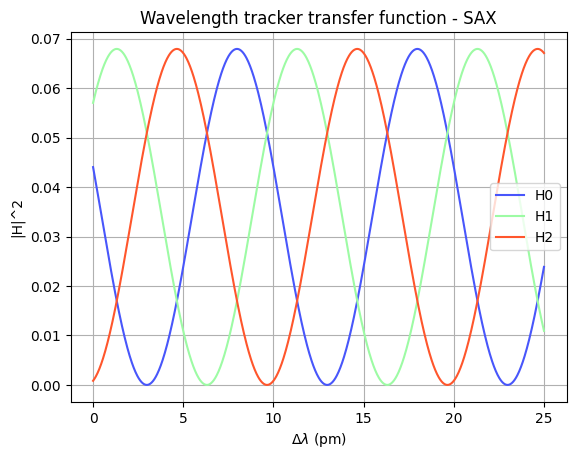

In [4]:
wls = jnp.linspace(1.55000, 1.550025, 1000)
loss_soi_dB_cm = 1
loss_soi = loss_soi_dB_cm / 10000  # dB/um

l_short = 2432.432
delta_l = 123822.6765655562
l_large = l_short + delta_l

test = wvltracker(wl = wls, 
                  wvg_u={"wl":wls, "length": l_short, "loss":0},
                  wvg_d={"wl":wls, "length": l_large, "loss":loss_soi},)

h0 = test["in0", "out0"]
h1 = test["in0", "out1"]
h2 = test["in0", "out2"]

H0 = np.abs(h0)**2
H1 = np.abs(h1)**2
H2 = np.abs(h2)**2

wl0 = 1.55
dl_pm = (np.asarray(wls) - wl0) * 1e6  # um -> pm

plt.plot(dl_pm, H0, linestyle = '-', color = color[1], label = 'H0')
plt.plot(dl_pm, H1, linestyle = '-', color = color[5], label = 'H1')
plt.plot(dl_pm, H2, linestyle = '-', color = color[8], label = 'H2')
plt.xlabel("$\Delta \lambda$ (pm)")
plt.ylabel('|H|^2')
plt.title('Wavelength tracker transfer function - SAX')
plt.legend()
plt.grid(True)

plt.show()

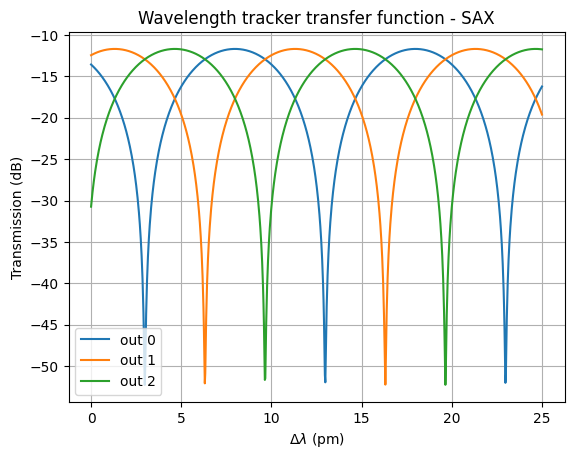

In [5]:
eps = 1e-15

H0_dB = 10 * np.log10(H0 + eps)
H1_dB = 10 * np.log10(H1 + eps)
H2_dB = 10 * np.log10(H2 + eps)


plt.plot(dl_pm, H0_dB, label="out 0")
plt.plot(dl_pm, H1_dB, label="out 1")
plt.plot(dl_pm, H2_dB, label="out 2")

plt.xlabel(r"$\Delta\lambda$ (pm)")
plt.ylabel("Transmission (dB)")
plt.title("Wavelength tracker transfer function - SAX")
plt.legend()
plt.grid(True)
plt.show()

In [6]:
from scipy.signal import find_peaks

peaks, _ = find_peaks(H0)

peak_wls = np.asarray(wls)[peaks]
fsrs_pm = np.diff(peak_wls) * 1e6

print("FSR medio [pm]:", np.mean(fsrs_pm))
print("FSR std [pm]:", np.std(fsrs_pm))

FSR medio [pm]: 9.9849849850564
FSR std [pm]: 0.0
